# Problématique

## Formulation du problème

Dans ce notebook, le problème est formulé comme une **classification multiclasse** 
à partir d'images médicales.

L'objectif n'est pas uniquement de détecter la présence de pneumonie, mais de 
**distinguer trois états cliniques distincts** : poumon normal, pneumonie 
bactérienne et pneumonie virale — distinction qui oriente directement le 
traitement antibiotique ou antiviral.

## Objectifs de modélisation

- **Définir les classes** : Normal (0), Bactérienne (1), Virale (2)
- **Entraîner un modèle CNN** par Transfer Learning sur EfficientNetB0
- **Produire une explication visuelle** via Grad-CAM pour chaque prédiction
- **Comparer les performances** par classe avec des métriques adaptées

## Cibles du problème

La variable cible est la classe de l'image :
1. `NORMAL` : poumon sain
2. `BACTERIA` : pneumonie bactérienne
3. `VIRUS` : pneumonie virale

## Déséquilibre des classes

Le dataset présente un déséquilibre marqué entre les classes — explicitement 
pris en compte via des class weights pendant l'entraînement.

## Métrique principale

La métrique principale est l'**AUC-ROC par classe** (approche One-vs-Rest), 
car elle mesure la capacité du modèle à discriminer chaque classe 
indépendamment du seuil de décision.

L'accuracy seule n'est pas suffisante sur un dataset déséquilibré.

# Analyse Exploratoire des Données

#### Vérification GPU + imports

In [4]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import Image
import shutil 

# Vérifier le GPU
print(f'GPU Disponible :{tf.config.list_physical_devices('GPU')}')
print(f'Version disponible : {tf.__version__}')

GPU Disponible :[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Version disponible : 2.19.0


#### Vérification du dataset

In [5]:

base_dir = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray"

print(os.listdir(base_dir))
for val in os.listdir(base_dir):
    pd.value_counts(val)


['chest_xray', '__MACOSX', 'val', 'test', 'train']


/tmp/ipykernel_55/3632799331.py:5: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(val)
/tmp/ipykernel_55/3632799331.py:5: FutureWarning: value_counts with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  pd.value_counts(val)
/tmp/ipykernel_55/3632799331.py:5: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(val)
/tmp/ipykernel_55/3632799331.py:5: FutureWarning: value_counts with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  pd.value_counts(val)
/tmp/ipykernel_55/3632799331.py:5: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(val)
/

#### Bacteria vs Virus

In [6]:
pneumonia = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train/PNEUMONIA/'

bacteria = [f for f in os.listdir(pneumonia) if 'bacteria' in f]

virus = [f for f in os.listdir(pneumonia) if 'virus' in f]
print(len(bacteria))
print(len(virus))



2530
1345


#### Distribution des 3 classes

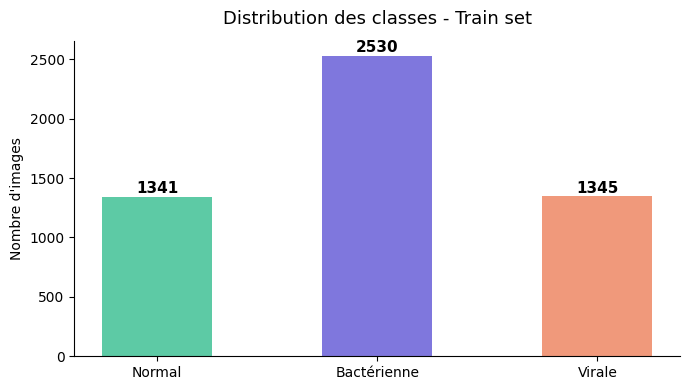

In [7]:
normal_n    = len(os.listdir(os.path.join(base_dir, "train", "NORMAL")))
bacteria_n  = len(bacteria)
virus_n     = len(virus)

classes = ["Normal", "Bactérienne", "Virale"]
counts  = [normal_n, bacteria_n, virus_n]
colors  = ["#5DCAA5", "#7F77DD", "#F0997B"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(classes, counts, color=colors, width=0.5)
ax.set_title("Distribution des classes - Train set", fontsize=13, pad=12)
ax.set_ylabel("Nombre d'images")

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            str(count), ha='center', fontsize=11, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.savefig("distribution_classes.png", dpi=150) 
plt.show()

#### Visualiser des images des 3 classes côte à côte

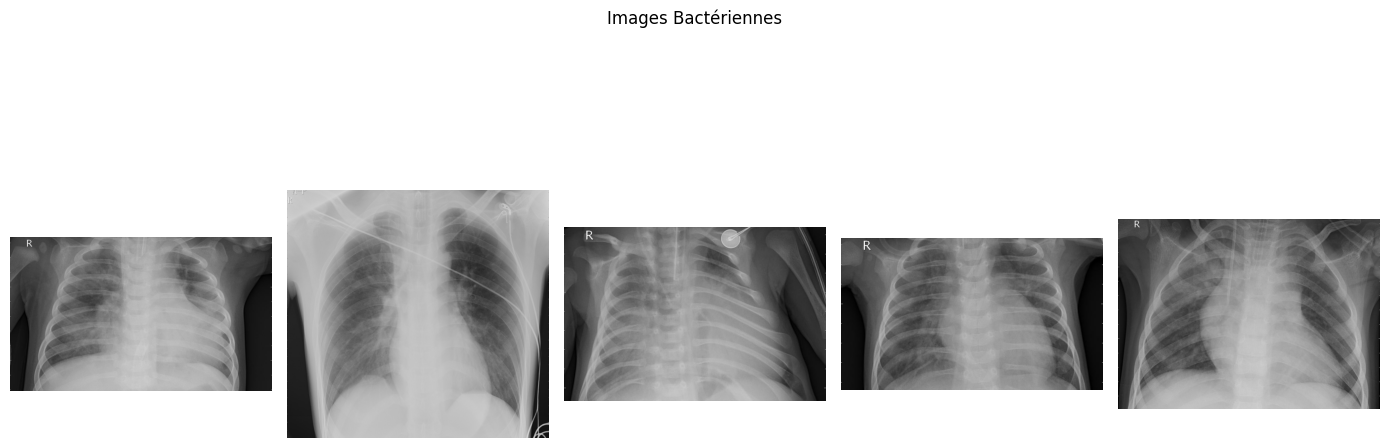

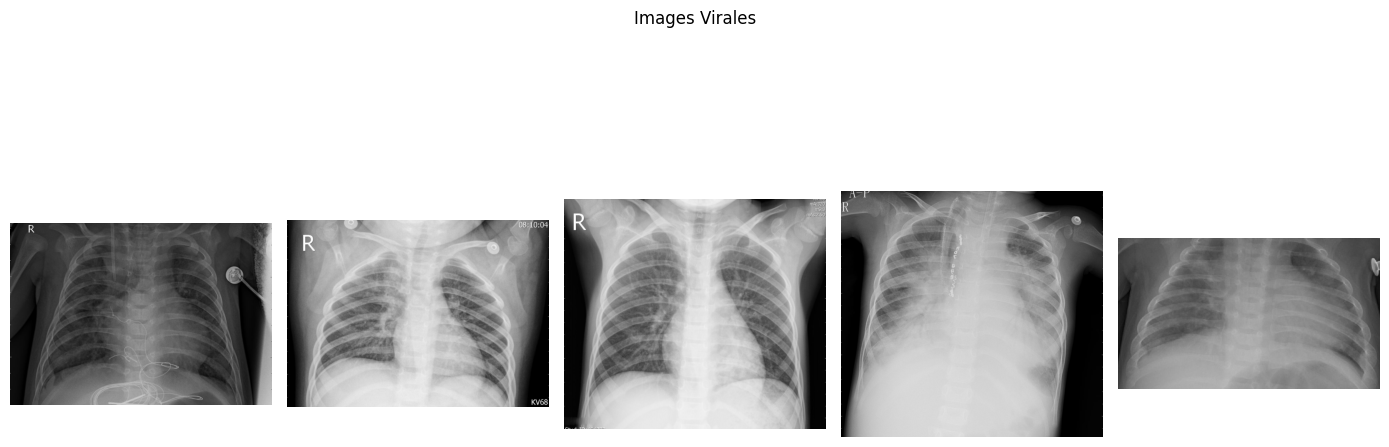

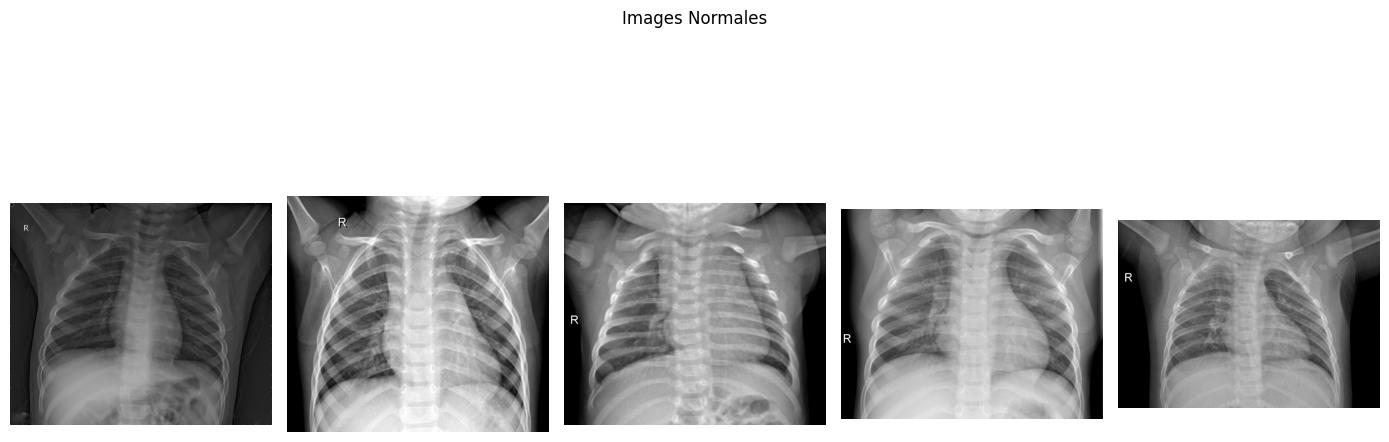

In [8]:
train_dir = os.path.join(base_dir, "train")
normal = os.path.join(train_dir, "NORMAL")
normal_files = os.listdir(normal)


def afficher_images(dossier, fichiers, titre, n=5):
    fig, ax = plt.subplots(1, n, figsize=(14, 6))
    
    for i in range(n):
        chemin = os.path.join(dossier, fichiers[i])  # chemin complet
        img = Image.open(chemin).convert("RGB")      # ouvrir image
        
        ax[i].imshow(img)                            # afficher
        ax[i].axis('off')                            # enlever axes
    
    fig.suptitle(titre)
    plt.tight_layout()
    plt.show()

afficher_images(pneumonia, bacteria, "Images Bactériennes")
afficher_images(pneumonia, virus, "Images Virales")
afficher_images(normal, normal_files, "Images Normales")

#### Vérifier la variabilité des tailles d'images

In [9]:
widths, heights = [], []

# Échantillon d'images
all_files = (
    [(normal, f) for f in normal_files[:34]] +
    [(pneumonia, f) for f in bacteria[:33]] +
    [(pneumonia, f) for f in virus[:33]]
)

for folder, fname in all_files:
    try:
        chemin = os.path.join(folder, fname)
        w, h = Image.open(chemin).size
        
        widths.append(w)
        heights.append(h)
    except:
        pass

print(f"Largeur  - min: {min(widths)}  max: {max(widths)}  moyenne: {int(np.mean(widths))}")
print(f"Hauteur  - min: {min(heights)} max: {max(heights)} moyenne: {int(np.mean(heights))}")

Largeur  - min: 703  max: 2400  moyenne: 1350
Hauteur  - min: 457 max: 2121 moyenne: 1003


# Pipeline de données

#### Réorganiser les fichiers

In [10]:
import os
import shutil

base = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray'
dest = '/kaggle/working/chest_xray'

# Créer tous les dossiers
for split in ['train', 'val', 'test']:
    for cls in ['NORMAL', 'BACTERIA', 'VIRUS']:
        os.makedirs(f"{dest}/{split}/{cls}", exist_ok=True)

# Copier NORMAL
for split in ['train', 'val', 'test']:
    source = f"{base}/{split}/NORMAL"
    destination = f"{dest}/{split}/NORMAL"
    for fichier in os.listdir(source):
        shutil.copy(os.path.join(source, fichier), destination)

# Trier PNEUMONIA en BACTERIA et VIRUS
for split in ['train', 'val', 'test']:
    source = f"{base}/{split}/PNEUMONIA"
    for fichier in os.listdir(source):
        if 'bacteria' in fichier.lower():
            shutil.copy(os.path.join(source, fichier), f"{dest}/{split}/BACTERIA")
        elif 'virus' in fichier.lower():
            shutil.copy(os.path.join(source, fichier), f"{dest}/{split}/VIRUS")

# Vérifier la structure
print("VÉRIFICATION DE LA STRUCTURE\n")
for split in ['train', 'val', 'test']:
    print(f"{split.upper()}/")
    for cls in ['NORMAL', 'BACTERIA', 'VIRUS']:
        n = len(os.listdir(f"{dest}/{split}/{cls}"))
        print(f"  {cls} : {n} images")
    print()

VÉRIFICATION DE LA STRUCTURE

TRAIN/
  NORMAL : 1342 images
  BACTERIA : 2530 images
  VIRUS : 1345 images

VAL/
  NORMAL : 9 images
  BACTERIA : 8 images
  VIRUS : 0 images

TEST/
  NORMAL : 234 images
  BACTERIA : 242 images
  VIRUS : 148 images



#### Créer les datasets avec image_dataset_from_directory (3 classes)

In [27]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    '/kaggle/working/chest_xray/train',
    validation_split=0.2,
    subset='training',
    image_size=(224, 224),
    batch_size=32,
    shuffle=True,
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    '/kaggle/working/chest_xray/train',
    validation_split=0.2,
    subset='validation',
    image_size=(224, 224),
    batch_size=32,
    shuffle=False,
    seed=42
)

Found 5216 files belonging to 3 classes.
Using 4173 files for training.
Found 5216 files belonging to 3 classes.
Using 1043 files for validation.


In [28]:
print(train_ds.class_names)
# ['BACTERIA', 'NORMAL', 'VIRUS']

# Voir la forme d'un batch
for images, labels in train_ds.take(1):
    print(images.shape)  # (32, 224, 224, 3)
    print(labels.shape)  # (32,)
    print(labels)        # [0, 1, 2, 0, 1, ...]

['BACTERIA', 'NORMAL', 'VIRUS']
(32, 224, 224, 3)
(32,)
tf.Tensor([2 1 0 1 0 0 0 1 1 2 0 2 2 1 2 0 0 0 0 1 0 1 1 1 0 1 0 0 1 2 1 2], shape=(32,), dtype=int32)


In [29]:
print(val_ds.class_names)

for images , labels in val_ds.take(1):
    print(images.shape)
    print(labels.shape)
    print(labels)

['BACTERIA', 'NORMAL', 'VIRUS']
(32, 224, 224, 3)
(32,)
tf.Tensor([2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2], shape=(32,), dtype=int32)


In [15]:
test_ds= tf.keras.utils.image_dataset_from_directory(
    '/kaggle/working/chest_xray/test',
    image_size=(224, 224),
    batch_size=32,
    shuffle=False,# car on a pas besoin  de modifier l'ordre popur val et test 
    seed=42
)


Found 624 files belonging to 3 classes.


#### Déséquilibre des classes

In [30]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Récupérer tous les labels du train
labels = []
for images, label_batch in train_ds:
    labels.extend(label_batch.numpy())

labels = np.array(labels)

# Calculer les poids
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

# Convertir en float Python (plus robuste avec Keras)
class_weight_dict = {int(i): float(w) for i, w in enumerate(class_weights)}
print(class_weight_dict)

{0: 0.6762275157997083, 1: 1.3400770712909442, 2: 1.290352504638219}


#### Optimisation du pipeline 

In [18]:
AUTOTUNE = tf.data.AUTOTUNE

# EfficientNetB0 (tf.keras.applications) gère déjà le prétraitement attendu.
# On optimise ici le pipeline sans appliquer de normalization_layer externe.
train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

# Transfer Learning

In [19]:
base_model = tf.keras.applications.EfficientNetB0(
    weights='imagenet',
    include_top = False,
    input_shape = (224,224,3)    
)
print("Nombre de couches :", len(base_model.layers))

base_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Nombre de couches : 238


#### Construire la tête et assembler le modèle

In [20]:
from tensorflow.keras.layers import (Dense, Dropout, GlobalAveragePooling2D,
                                     RandomFlip, RandomRotation, RandomZoom)

model = tf.keras.Sequential([
    # Augmentation
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),
    
    # Corps EfficientNet
    base_model,
    
    # Aplatir
    GlobalAveragePooling2D(),
    
    # Couche cachée
    Dense(128, activation='relu'),
    
    # Régularisation
    Dropout(0.3),
    
    # Sortie
    Dense(3, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ ?                      │   0 (unbuilt) │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)

In [21]:
model.build(input_shape=(None, 224, 224, 3))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,926 (16.07 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

#### Compilation

In [23]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        'accuracy',
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=2, name='top2_acc')
    ]
)

#### Callbacks

In [25]:

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.h5",
    monitor='val_loss',
    save_best_only=True
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2
)

In [31]:
# Vérification rapide: dataset non vide avant entraînement
train_batches = tf.data.experimental.cardinality(train_ds).numpy()
val_batches = tf.data.experimental.cardinality(val_ds).numpy()
print(f"Batches train={train_batches}, val={val_batches}")

if train_batches <= 0 or val_batches <= 0:
    raise ValueError("train_ds ou val_ds est vide. Vérifie les dossiers source.")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weight_dict,
    callbacks=[checkpoint, early_stop, reduce_lr]
 )

Batches train=131, val=33
Epoch 1/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.7790 - loss: 0.4739 - top2_acc: 0.9797

131/131 ━━━━━━━━━━━━━━━━━━━━ 16s 120ms/step - accuracy: 0.7791 - loss: 0.4737 - top2_acc: 0.9797 - val_accuracy: 0.7689 - val_loss: 0.5843 - val_top2_acc: 0.9885 - learning_rate: 8.0000e-06
Epoch 2/15
130/131 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.7789 - loss: 0.4751 - top2_acc: 0.9790

131/131 ━━━━━━━━━━━━━━━━━━━━ 15s 110ms/step - accuracy: 0.7790 - loss: 0.4748 - top2_acc: 0.9790 - val_accuracy: 0.7689 - val_loss: 0.5842 - val_top2_acc: 0.9885 - learning_rate: 8.0000e-06
Epoch 3/15
130/131 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.7780 - loss: 0.4799 - top2_acc: 0.9804

131/131 ━━━━━━━━━━━━━━━━━━━━ 14s 109ms/step - accuracy: 0.7781 - loss: 0.4796 - top2_acc: 0.9804 - val_accuracy: 0.7718 - val_loss: 0.5784 - val_top2_acc: 0.9895 - learning_rate: 8.0000e-06
Epoch 4/15
130/131 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.7783 - loss: 0.4681 - top2_acc: 0.9807

131/131 ━━━━━━━━━━━━━━━━━━━━ 14s 108ms/step - accuracy: 0.7784 - loss: 0.4679 - top2_acc: 0.9807 - val_accuracy: 0.7718 - val_loss: 0.5747 - val_top2_acc: 0.9895 - learning_rate: 8.0000e-06
Epoch 5/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 14s 106ms/step - accuracy: 0.7762 - loss: 0.4803 - top2_acc: 0.9780 - val_accuracy: 0.7699 - val_loss: 0.5800 - val_top2_acc: 0.9895 - learning_rate: 8.0000e-06
Epoch 6/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 14s 107ms/step - accuracy: 0.7828 - loss: 0.4711 - top2_acc: 0.9764 - val_accuracy: 0.7737 - val_loss: 0.5833 - val_top2_acc: 0.9885 - learning_rate: 8.0000e-06
Epoch 7/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 14s 108ms/step - accuracy: 0.7817 - loss: 0.4720 - top2_acc: 0.9814 - val_accuracy: 0.7737 - val_loss: 0.5847 - val_top2_acc: 0.9885 - learning_rate: 1.6000e-06


In [32]:
base_model.trainable = True

# Geler tout sauf les 30 dernières couches
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Vérifier combien de couches sont maintenant entraînables
trainable = sum([l.trainable for l in base_model.layers])
print(f"Couches entraînables dans base_model : {trainable}")

Couches entraînables dans base_model : 30


In [34]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
   metrics=[
        'accuracy',
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=2, name='top2_acc')
    ]
)

In [35]:
history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weight_dict,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

Epoch 1/15


E0000 00:00:1777102159.676473      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


131/131 ━━━━━━━━━━━━━━━━━━━━ 32s 139ms/step - accuracy: 0.7033 - loss: 0.6498 - top2_acc: 0.9288 - val_accuracy: 0.7057 - val_loss: 0.7027 - val_top2_acc: 0.9463 - learning_rate: 1.0000e-05
Epoch 2/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 16s 119ms/step - accuracy: 0.7066 - loss: 0.6181 - top2_acc: 0.9331 - val_accuracy: 0.6846 - val_loss: 0.7251 - val_top2_acc: 0.9406 - learning_rate: 1.0000e-05
Epoch 3/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 15s 118ms/step - accuracy: 0.7461 - loss: 0.5722 - top2_acc: 0.9485 - val_accuracy: 0.7172 - val_loss: 0.6716 - val_top2_acc: 0.9501 - learning_rate: 1.0000e-05
Epoch 4/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 16s 118ms/step - accuracy: 0.7372 - loss: 0.5643 - top2_acc: 0.9597 - val_accuracy: 0.7239 - val_loss: 0.6486 - val_top2_acc: 0.9530 - learning_rate: 1.0000e-05
Epoch 5/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 16s 118ms/step - accuracy: 0.7494 - loss: 0.5456 - top2_acc: 0.9629 - val_accuracy: 0.7488 - val_loss: 0.5859 - val_top2_acc: 0.9636 - learning_rate: 1.0000e-05
Epoch 

#### commentaire 